### Импорты, seed и среда

In [ ]:
import os
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

import datasets
from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    pipeline,
    Trainer,
    TrainingArguments,
)

In [48]:
print("datasets:", datasets.__version__)
print("transformers:",transformers.__version__)
print("torch:",torch.__version__)

datasets: 4.0.0
transformers: 5.0.0
torch: 2.10.0+cu128


In [2]:
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed = 42
set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [4]:
os.makedirs("artifacts", exist_ok=True)

### Данные и первичный анализ

In [5]:
ds = load_dataset("alt-gnome/telegram-spam")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/477 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21411 [00:00<?, ? examples/s]

In [7]:
labels = ds['train']['label']
label_names = sorted(set(labels))
label_counts = pd.Series(labels).value_counts().sort_index()
label_counts

,count
0,14400
1,7011


In [8]:
train_test_split = ds['train'].train_test_split(test_size=0.2, seed=seed, stratify_by_column="label")
test_ds = train_test_split['test']

train_val_split = train_test_split['train'].train_test_split(test_size=0.25, seed=seed, stratify_by_column="label")
train_ds = train_val_split['train']
val_ds = train_val_split['test']

In [49]:
print(f"Train: {len(train_ds)}")
print(f"Val:   {len(val_ds)}")
print(f"Test:  {len(test_ds)}")

Train: 12846
Val:   4282
Test:  4283


In [10]:
dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 12846
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4282
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4283
    })
})

In [37]:
demo_samples = dataset_dict["train"][:10]
display(pd.DataFrame(demo_samples))

,text,label
0,"Модуль активировал, но все равно на клиенте нет доступа в интернет. Что не так делаю?",0
1,"Vnc рвёт цитрикс во всём, кроме звука. По производительности рабочего стола и цитрикса близко нет рядом с vnc, а еще vnc абсолютно беспл...",0
2,"Христос Всокрес нужно убрать в гараже, кто может помочь заплачу 2OOO рублей, с меня мясо, пишите договоримся",1
3,"Восстановить из резервной копии. Например, сделанной с помощью Timeshift.",0
4,"Ох, если бы я знал как это проверить... \nКакую команду в терминале ввести нужно?",0
5,"Привет! Ищу пару ответственных людей (от 18 лет) для удалённой работы (легально). Если заинтересованы, пишите в личные сообщения - +",1
6,"У меня после перехода было мучение, но не долго. Это давно было.\nБыл гном 2. Обновился выпуск и стало юнити.\nЭто были незабываемые 20 ...",0
7,"Нужны ответственные люди в команду. 21+\nДоход от 4000 долларов за месяц, полностью дистанционный формат.\nПишите + мне в личные сообщения.",1
8,"Спасибо, буду ещё пробовать, нет, так придётся возвращаться на xrdp, там всё хорошо, кроме отсутствия возможности входа в текущую сесс...",0
9,Вручную через переменные среды окружения.,0


Датасет содержит сообщения, которые как относятся, так и не относятся к спаму.

Классы:
- `0` - не спам
- `1` - спам

### Токенизация

In [12]:
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: BertTokenizer
Model checkpoint: cointegrated/rubert-tiny2


In [42]:
demo_texts = demo_samples['text'][-3:]

for text in demo_texts:
    encoded_text = tokenizer(text)
    tokens = tokenizer.convert_ids_to_tokens(encoded_text['input_ids'])
    print(f"Text: {text}")
    print(f"Tokens: {tokens}")
    print(f"Input IDs: {encoded_text['input_ids']}")
    print()

Text: Нужны ответственные люди в команду. 21+
Доход от 4000 долларов за месяц, полностью дистанционный формат.
Пишите + мне в личные сообщения.
Tokens: ['[CLS]', 'Нужны', 'ответственные', 'люди', 'в', 'команду', '.', '21', '+', 'Доход', 'от', '4000', 'долларов', 'за', 'месяц', ',', 'полностью', 'дистанционный', 'формат', '.', 'Пиш', '##ите', '+', 'мне', 'в', 'личные', 'сообщения', '.', '[SEP]']
Input IDs: [2, 78257, 57677, 9022, 314, 7592, 18, 704, 15, 79583, 733, 6452, 12699, 650, 24226, 16, 9297, 67599, 29416, 18, 54668, 2205, 15, 20284, 314, 36155, 25358, 18, 3]

Text: Спасибо,  буду ещё пробовать, нет, так придётся возвращаться на xrdp, там всё хорошо,  кроме отсутствия возможности входа в текущую сессию пользователя.
Tokens: ['[CLS]', 'Спасибо', ',', 'буду', 'ещё', 'пробовать', ',', 'нет', ',', 'так', 'придётся', 'возвращаться', 'на', 'x', '##rd', '##p', ',', 'там', 'всё', 'хорошо', ',', 'кроме', 'отсутствия', 'возможности', 'входа', 'в', 'текущую', 'сессию', 'пользователя', '.', 

In [46]:
batch_encoded = tokenizer(
    demo_texts,
    padding=True,
    truncation=True,
    max_length=15,
    return_tensors="pt"
)

trunc_padding_demo = pd.DataFrame({
    "input_ids": batch_encoded["input_ids"].tolist(),
    "attention_mask": batch_encoded["attention_mask"].tolist()
})

print("После padding и truncation (max_length=15):")
display(trunc_padding_demo)

print("\nДекодированный текст последнего примера:")
print(tokenizer.decode(batch_encoded["input_ids"][-1]))

После padding и truncation (max_length=15):


,input_ids,attention_mask
0,"[2, 78257, 57677, 9022, 314, 7592, 18, 704, 15, 79583, 733, 6452, 12699, 650, 3]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,"[2, 32426, 16, 29727, 3952, 62796, 16, 10030, 16, 1908, 37057, 37813, 548, 91, 3]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
2,"[2, 63112, 11535, 2277, 81414, 24059, 41242, 18, 3, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]"



Декодированный текст последнего примера:
[CLS] Вручную через переменные среды окружения. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [15]:
def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256,
    )

tokenized_dataset = dataset_dict.map(tokenize_batch, batched=True)

tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset

Map:   0%|          | 0/12846 [00:00<?, ? examples/s]

Map:   0%|          | 0/4282 [00:00<?, ? examples/s]

Map:   0%|          | 0/4283 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12846
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4282
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4283
    })
})

In [17]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

### Инференс готовой модели

In [18]:
model_pipeline = pipeline("text-classification", model="RUSpam/spam_deberta_v4", device=device)
pipeline_outputs = model_pipeline(demo_texts)

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/86 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [19]:
pipeline_df = pd.DataFrame(
    {
        "text": demo_texts,
        "actual_label": demo_samples["label"],
        "predicted_label": [item["label"] for item in pipeline_outputs],
        "score": [item["score"] for item in pipeline_outputs],
    }
)

pipeline_df

,text,actual_label,predicted_label,score
0,"Модуль активировал, но все равно на клиенте нет доступа в интернет. Что не так делаю?",0,LABEL_0,0.9995
1,"Vnc рвёт цитрикс во всём, кроме звука. По производительности рабочего стола и цитрикса близко нет рядом с vnc, а еще vnc абсолютно беспл...",0,LABEL_0,1.0000
2,"Христос Всокрес нужно убрать в гараже, кто может помочь заплачу 2OOO рублей, с меня мясо, пишите договоримся",1,LABEL_1,0.9983
3,"Восстановить из резервной копии. Например, сделанной с помощью Timeshift.",0,LABEL_0,1.0000
4,"Ох, если бы я знал как это проверить... \nКакую команду в терминале ввести нужно?",0,LABEL_0,1.0000


In [20]:
val_texts = dataset_dict['validation'][:]['text']
val_labels = np.array(dataset_dict['validation']['label'])

pipe_results = model_pipeline(val_texts, truncation=True)

In [53]:
pipe_preds = np.array([int(res['label'].split('_')[-1]) for res in pipe_results])

acc = accuracy_score(val_labels, pipe_preds)
f1_macro = f1_score(val_labels, pipe_preds, average="macro")
f1_weighted = f1_score(val_labels, pipe_preds, average="weighted")

print("Оценка готовой модели на validation:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Оценка готовой модели на validation:
Accuracy: 0.9937
F1 Macro: 0.9928
F1 Weighted: 0.9937


Модель `RUSpam/spam_deberta_v4` была предобучена под задачу обнаружения спама, потому на схожих данных результаты показывает высокие.

### Fine-tuning для классификации текста

In [22]:
id2label = {0: "not_spam", 1: "spam"}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Model class: BertForSequenceClassification
Number of labels: 2
id2label: {0: 'not_spam', 1: 'spam'}


In [23]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [24]:
common_training_kwargs = dict(
    output_dir="outputs/rubert_finetuning_demo",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=seed,
    report_to="none",
)

training_args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    **common_training_kwargs,
)

In [25]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.000313,0.026725,0.994862,0.994169,0.994863
2,0.000165,0.022806,0.996030,0.995495,0.996031
3,0.000118,0.022905,0.996030,0.995495,0.996031


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=4818, training_loss=0.021144829699698577, metrics={'train_runtime': 126.16, 'train_samples_per_second': 305.469, 'train_steps_per_second': 38.19, 'total_flos': 44658370279632.0, 'train_loss': 0.021144829699698577, 'epoch': 3.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.7088,1.8053,4.9990e-05,0.0012,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.6779,1.2839,4.9969e-05,0.0025,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.6285,2.5148,4.9948e-05,0.0037,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.6689,1.2929,4.9927e-05,0.0050,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.6490,1.9369,4.9907e-05,0.0062,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.6108,1.8844,4.9886e-05,0.0075,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.6445,1.1951,4.9865e-05,0.0087,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.5953,1.5160,4.9844e-05,0.0100,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.5727,1.3346,4.9824e-05,0.0112,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.5538,1.2854,4.9803e-05,0.0125,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


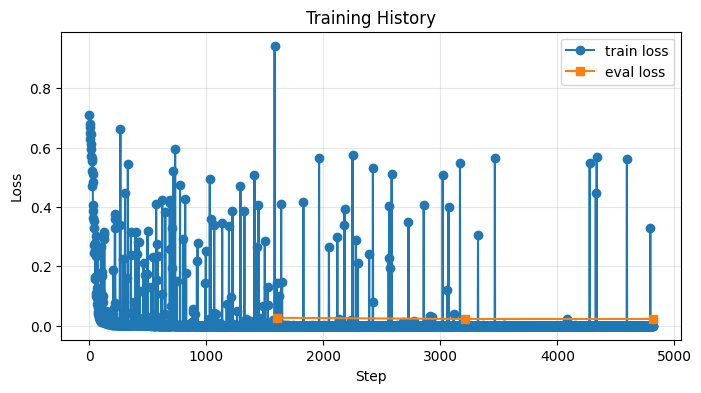

In [26]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("Training History")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Оценка качества и краткий анализ ошибок

In [27]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

val_metrics = trainer.evaluate(tokenized_dataset["validation"])
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

Validation metrics:
eval_loss: 0.0228
eval_accuracy: 0.9960
eval_f1_macro: 0.9955
eval_f1_weighted: 0.9960
eval_runtime: 3.1162
eval_samples_per_second: 1374.1050
eval_steps_per_second: 172.0040
epoch: 3.0000

Test metrics:
eval_loss: 0.0171
eval_accuracy: 0.9963
eval_f1_macro: 0.9958
eval_f1_weighted: 0.9963
eval_runtime: 3.6403
eval_samples_per_second: 1176.5510
eval_steps_per_second: 147.2410
epoch: 3.0000


In [28]:
test_output = trainer.predict(tokenized_dataset["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

Classification report on test:
              precision    recall  f1-score   support

    not_spam       1.00      1.00      1.00      2881
        spam       0.99      0.99      0.99      1402

    accuracy                           1.00      4283
   macro avg       1.00      1.00      1.00      4283
weighted avg       1.00      1.00      1.00      4283



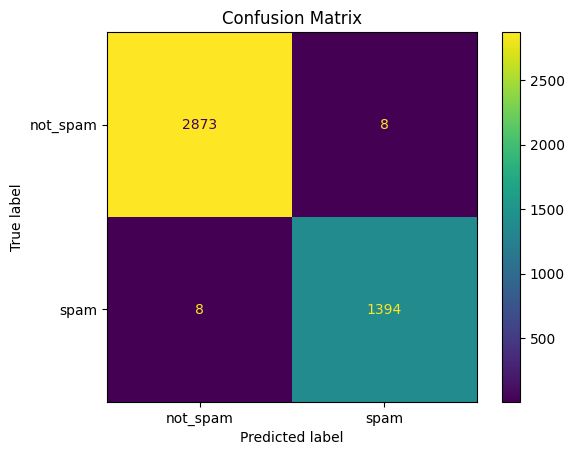

In [29]:
target_names = ["not_spam", "spam"]

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=target_names,
        zero_division=0,
    )
)

cmd = ConfusionMatrixDisplay.from_predictions(test_true, test_preds, display_labels=target_names)

plt.title("Confusion Matrix")
plt.savefig("artifacts/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
probs = F.softmax(torch.tensor(test_logits), dim=-1).numpy()
confidences = probs.max(axis=-1)

results_df = pd.DataFrame({
    "text": test_ds["text"],
    "true_label": [id2label[l] for l in test_true],
    "pred_label": [id2label[p] for p in test_preds],
    "confidence": confidences
})

display(results_df.head(10))

,text,true_label,pred_label,confidence
0,Оценочное суждение с резко отрицательной коннотацией.,not_spam,not_spam,0.9999
1,"Он чисто консольный, для обычного пользователя не подойдет",not_spam,not_spam,0.9999
2,Лёгкий старт в онлайн-проекте:\n💵 Доход от $100 в день\n🕒 Всего 1 час в день\n📍 Без опыта\nПодробности — в личных сообщениях.,spam,spam,0.9999
3,"Ну, всю систему это долго. Но и это можно, если аккуратно.",not_spam,not_spam,0.9999
4,Предлагаю долгосрочное сотрудничество в сфере crypto \nС моей стороны информация по сделкам - с вас % от чистого дохода \nНе прошу ваших...,spam,spam,0.9999
5,"Привет! Ищу амбициозных и целеустремленных людей для выгодного сотрудничества. Доход от $3,900 в месяц, всё в удобном дистанционном форм...",spam,spam,0.9999
6,"это личное предпочтение, но всё же в связи с \nтем что btrfs всё жэ удобнее для переноса данных с одного накопителя на другой, чем ext",not_spam,not_spam,0.9999
7,"Ну, дык, p11\n\nalt-p11-jeos-systemd-20241212-x86_64.iso",not_spam,not_spam,0.9999
8,"Т.е. хотите видеть ""внутреннюю кухню"" рейд-контроллера? Возможно, это работает через драйвер, поддерживающий этот аппаратный контроллер....",not_spam,not_spam,0.9999
9,"это остатки от другого домена, эксперименты",not_spam,not_spam,0.9999


In [35]:
errors_df = results_df[results_df["true_label"] != results_df["pred_label"]]
display(errors_df.head(10))

,text,true_label,pred_label,confidence
129,"Здравствуйте. У меня остались курсы по трейдингу, если кому по душе, могу скинуть просто так",spam,not_spam,0.6786
197,Так правдивый и нужен.,spam,not_spam,0.9999
1126,"Отдам стиральную машинку , брала в том году, новая",spam,not_spam,0.8971
1321,У них прибыль в несколько раз больше,not_spam,spam,0.9958
1386,"Привет, кто-то просил с группы ссылку на курьера, закинула в профиль",spam,not_spam,0.9971
1513,"Без танцев с бубном , у людей только RU сайты работают.Спасибо РКН за Чебурнет",not_spam,spam,0.9924
1775,Ищу наиболее удобные 😅,not_spam,spam,0.9991
2576,С флэшки ставят ... приезжают за 100 километров от центра и переустанавливуют рабочие станции!!! Какая автоматизация!!!,not_spam,spam,0.9958
2590,"🎉ТОП-1 КАЗИК ПРЯМО В TELEGRAMM, САМЫЕ, БОЛЬШИЕ ВЫЙГРЫШИ.",spam,not_spam,0.6552
2724,"биток летит вниз, а WarForGalaxy вверх",spam,not_spam,0.9998


Видно, что на ярких примерах пропущенного спама уверенность модели обычно существенно ниже, чем в остальных случаях.  
И насколько верно изначальное отнесение второго текста к спаму - вопрос.

In [41]:
sample_df = pd.concat([results_df.head(10), errors_df.head(10)], axis=0)
sample_df.to_csv("artifacts/sample_predictions.csv", index=False)